# 06. Random Forest: wiele drzew na problemie churn

Cel: pokazać, jak przejść od pojedynczego drzewa decyzyjnego do **lasu losowego**.

Po tym notebooku student powinien rozumieć:

1. dlaczego pojedyncze drzewo bywa niestabilne,
2. czym jest bootstrap i losowy podzbiór cech,
3. jak działa głosowanie wielu drzew,
4. jak porównać `DecisionTreeClassifier` z `RandomForestClassifier`,
5. dlaczego Random Forest zwykle jest mocniejszy, ale mniej interpretowalny.

## Punkt wyjścia z poprzedniego notebooka

W notebooku 05 nauczyliśmy pojedyncze drzewo na danych churn (wskaźnik rezygnacji).

Wyniki były ograniczone:

```text
baseline accuracy: 0.722
pojedyncze drzewo accuracy: 0.653
recall dla klasy tak: 0.25
```

## Co zobaczymy w tym notebooku:

Notebook 06 już pokazuje bardzo dobry wynik porównawczy:
```
baseline accuracy:        0.722
pojedyncze drzewo test:   0.653
Random Forest test:       0.750
```

## 1. Dane i punkt startowy

Wracamy do problemu churn: chcemy przewidzieć, czy klient odejdzie z usługi.

Używamy podobnego pipeline'u jak w notebooku 05:

- cechy liczbowe uzupełniamy medianą,
- cechy kategoryczne uzupełniamy najczęstszą wartością,
- kategorie kodujemy przez one-hot encoding,
- porównujemy pojedyncze drzewo z lasem losowym.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

BASE = Path.cwd()
for candidate in [BASE, BASE.parent, Path("/mnt/data/drzewa_decyzyjne_dydaktyka")]:
    if (candidate / "data" / "04_klienci_churn.csv").exists():
        BASE = candidate
        break
else:
    BASE = Path.cwd()

csv_path = BASE / "data" / "04_klienci_churn.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: te same kolumny co w notebooku 05.
    rng = np.random.default_rng(42)
    n = 240
    miesiace_umowy = rng.integers(1, 49, n)
    liczba_reklamacji = rng.poisson(1.1, n)
    srednie_logowania_tyg = np.clip(rng.normal(5.0, 2.3, n), 0, 14).round(1)
    plan = rng.choice(["basic", "pro", "premium"], size=n, p=[0.45, 0.38, 0.17]).astype(object)
    umowa = rng.choice(["miesieczna", "roczna", "dwuletnia"], size=n, p=[0.55, 0.30, 0.15]).astype(object)
    rabat = rng.choice(["tak", "nie"], size=n, p=[0.35, 0.65]).astype(object)

    logit = (
        0.0
        + 0.9 * (umowa == "miesieczna")
        + 0.45 * (plan == "basic")
        + 0.55 * (liczba_reklamacji >= 2)
        - 0.035 * miesiace_umowy
        - 0.18 * srednie_logowania_tyg
        - 0.25 * (rabat == "tak")
    )
    prob = 1 / (1 + np.exp(-logit))
    odejdzie = np.where(rng.random(n) < prob, "tak", "nie")

    df = pd.DataFrame({
        "klient_id": range(1, n + 1),
        "miesiace_umowy": miesiace_umowy,
        "liczba_reklamacji": liczba_reklamacji,
        "srednie_logowania_tyg": srednie_logowania_tyg,
        "plan": plan,
        "umowa": umowa,
        "rabat": rabat,
        "odejdzie": odejdzie,
    })

    df.loc[rng.choice(n, 10, replace=False), "srednie_logowania_tyg"] = np.nan
    df.loc[rng.choice(n, 7, replace=False), "plan"] = np.nan
    df.loc[rng.choice(n, 6, replace=False), "rabat"] = np.nan

df.head()

,klient_id,miesiace_umowy,liczba_reklamacji,srednie_logowania_tyg,plan,umowa,rabat,odejdzie
0,1,5,2,NaN,pro,dwuletnia,nie,nie
1,2,38,1,3.6,premium,miesieczna,tak,nie
2,3,32,1,3.5,basic,miesieczna,nie,tak
3,4,22,0,6.2,basic,roczna,nie,tak
4,5,21,0,6.8,pro,miesieczna,nie,nie


In [4]:
print(df.isna().sum())
print()
print(df["odejdzie"].value_counts(normalize=True).rename("proporcja"))

klient_id                 0
miesiace_umowy            0
liczba_reklamacji         0
srednie_logowania_tyg    10
plan                      7
umowa                     0
rabat                     6
odejdzie                  0
dtype: int64

nie    0.720833
tak    0.279167
Name: proporcja, dtype: float64


## 2. Wspólny preprocessing

Żeby porównanie było uczciwe, pojedyncze drzewo i Random Forest dostają dokładnie ten sam preprocessing.

In [5]:
X = df.drop(columns=["odejdzie", "klient_id"])
y = df["odejdzie"]

num_cols = ["miesiace_umowy", "liczba_reklamacji", "srednie_logowania_tyg"]
cat_cols = ["plan", "umowa", "rabat"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (168, 6)
Test:  (72, 6)


## 3. Pojedyncze drzewo jako punkt odniesienia

Najpierw uczymy zwykłe drzewo. To jest nasz model odniesienia: łatwy do narysowania i interpretacji, ale potencjalnie niestabilny.

In [6]:
tree_pipe = Pipeline([
    ("prep", preprocess),
    ("tree", DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=4,
        random_state=42
    ))
])

tree_pipe.fit(X_train, y_train)

tree_pred_train = tree_pipe.predict(X_train)
tree_pred_test = tree_pipe.predict(X_test)

print("Decision Tree train accuracy:", round(accuracy_score(y_train, tree_pred_train), 3))
print("Decision Tree test accuracy: ", round(accuracy_score(y_test, tree_pred_test), 3))

Decision Tree train accuracy: 0.774
Decision Tree test accuracy:  0.653


## 4. Random Forest

Random Forest buduje wiele drzew. Każde drzewo dostaje trochę inny losowy zestaw przykładów, bo uczy się na próbie bootstrapowej. Dodatkowo przy każdym splicie rozważa tylko losowy podzbiór cech.

Dzięki temu drzewa różnią się od siebie, a cały las jest zwykle stabilniejszy niż jedno drzewo.

In [7]:
forest_pipe = Pipeline([
    ("prep", preprocess),
    ("forest", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=1
    ))
])

forest_pipe.fit(X_train, y_train)

forest_pred_train = forest_pipe.predict(X_train)
forest_pred_test = forest_pipe.predict(X_test)

print("Random Forest train accuracy:", round(accuracy_score(y_train, forest_pred_train), 3))
print("Random Forest test accuracy: ", round(accuracy_score(y_test, forest_pred_test), 3))

Random Forest train accuracy: 0.827
Random Forest test accuracy:  0.75


## 5. Porównanie modeli

Nie zakładamy z góry, że Random Forest zawsze wygra. Sprawdzamy to empirycznie na zbiorze testowym.

In [17]:
baseline_class = y_train.mode().iloc[0]
baseline_pred = pd.Series([baseline_class] * len(y_test), index=y_test.index)

comparison = pd.DataFrame([
    {
        "model": "Baseline: najczęstsza klasa",
        "accuracy_train": np.nan,
        "accuracy_test": accuracy_score(y_test, baseline_pred),
    },
    {
        "model": "Pojedyncze drzewo",
        "accuracy_train": accuracy_score(y_train, tree_pred_train),
        "accuracy_test": accuracy_score(y_test, tree_pred_test),
    },
    {
        "model": "Random Forest",
        "accuracy_train": accuracy_score(y_train, forest_pred_train),
        "accuracy_test": accuracy_score(y_test, forest_pred_test),
    },
])

comparison

,model,accuracy_train,accuracy_test
0,Baseline: najczęstsza klasa,NaN,0.722222
1,Pojedyncze drzewo,0.773810,0.652778
2,Random Forest,0.827381,0.750000


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

positive_label = "tak"

metrics_comparison = pd.DataFrame({
    "model": ["baseline", "pojedyncze drzewo", "Random Forest"],
    "accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, tree_pred_test),
        accuracy_score(y_test, forest_pred_test),
    ],
    "precision_tak": [
        precision_score(y_test, baseline_pred, pos_label=positive_label, zero_division=0),
        precision_score(y_test, tree_pred_test, pos_label=positive_label, zero_division=0),
        precision_score(y_test, forest_pred_test, pos_label=positive_label, zero_division=0),
    ],
    "recall_tak": [
        recall_score(y_test, baseline_pred, pos_label=positive_label, zero_division=0),
        recall_score(y_test, tree_pred_test, pos_label=positive_label, zero_division=0),
        recall_score(y_test, forest_pred_test, pos_label=positive_label, zero_division=0),
    ],
    "f1_tak": [
        f1_score(y_test, baseline_pred, pos_label=positive_label, zero_division=0),
        f1_score(y_test, tree_pred_test, pos_label=positive_label, zero_division=0),
        f1_score(y_test, forest_pred_test, pos_label=positive_label, zero_division=0),
    ],
})

metrics_comparison

,model,accuracy,precision_tak,recall_tak,f1_tak
0,baseline,0.722222,0.000000,0.00,0.000000
1,pojedyncze drzewo,0.652778,0.333333,0.25,0.285714
2,Random Forest,0.750000,0.625000,0.25,0.357143


Random Forest ma najlepszą accuracy,
ale warto spojrzeć na klasę `tak`.

Widzimy, że recall dla `tak` nadal jest niski.
Model wykrywa tylko część klientów odchodzących.

Poprawia się natomiast precision:
gdy Random Forest mówi `tak`, częściej ma rację niż pojedyncze drzewo.

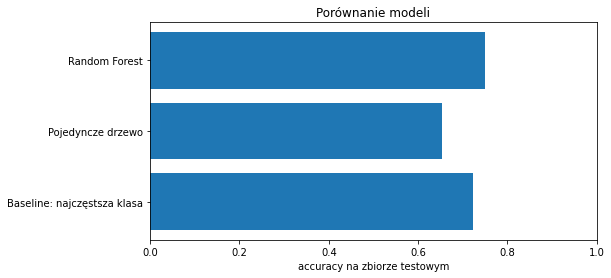

In [9]:
plt.figure(figsize=(8, 4))
plot_df = comparison.dropna(subset=["accuracy_test"])
plt.barh(plot_df["model"], plot_df["accuracy_test"])
plt.xlabel("accuracy na zbiorze testowym")
plt.title("Porównanie modeli")
plt.xlim(0, 1)
plt.show()

              precision    recall  f1-score   support

         nie       0.77      0.94      0.84        52
         tak       0.62      0.25      0.36        20

    accuracy                           0.75        72
   macro avg       0.70      0.60      0.60        72
weighted avg       0.73      0.75      0.71        72



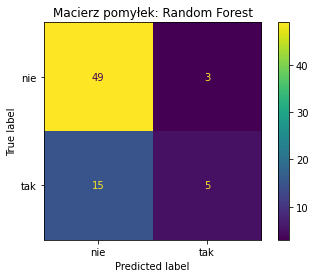

In [10]:
print(classification_report(y_test, forest_pred_test, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, forest_pred_test)
plt.title("Macierz pomyłek: Random Forest")
plt.show()

## Jak czytać macierz Random Forest?

Dla klasy `tak` interesują nas szczególnie dwa pola:

- prawdziwe `tak`, przewidziane `tak` — wykryci klienci odchodzący,
- prawdziwe `tak`, przewidziane `nie` — klienci odchodzący, których model przegapił.

W tym przykładzie Random Forest nadal przegapia znaczną część klientów odchodzących.

To pokazuje, że sama poprawa accuracy nie wystarcza.
W churn zwykle chcemy także poprawić recall dla klasy `tak`.

## Dlaczego wiele drzew może działać lepiej?

Pojedyncze drzewo może mocno zależeć od jednego podziału danych.

Jeśli pierwszy split będzie trochę inny,
całe drzewo może wyglądać inaczej.

Random Forest ogranicza ten problem:

- buduje wiele drzew,
- każde drzewo widzi trochę inne dane,
- każde drzewo widzi trochę inne cechy,
- końcowa decyzja jest głosowaniem.

Dzięki temu pojedynczy przypadkowy split ma mniejszy wpływ na końcową predykcję.

## 6. Jak rozumieć głosowanie lasu?

W klasyfikacji każde drzewo w lesie oddaje głos na klasę. Wynik `predict_proba()` można czytać jako udział głosów na poszczególne klasy.

In [11]:
sample = X_test.iloc[[0]]
print("Przykładowy klient:")
print(sample.to_string(index=False))
print("Prawdziwa etykieta:", y_test.iloc[0])
print("Predykcja lasu:", forest_pipe.predict(sample)[0])

proba = forest_pipe.predict_proba(sample)[0]
pd.DataFrame({
    "klasa": forest_pipe.named_steps["forest"].classes_,
    "udział_głosów / proba": proba
})

Przykładowy klient:
 miesiace_umowy  liczba_reklamacji  srednie_logowania_tyg  plan  umowa rabat
             10                  0                    2.0 basic roczna   nie
Prawdziwa etykieta: nie
Predykcja lasu: nie


,klasa,udział_głosów / proba
0,nie,0.866787
1,tak,0.133213


In [18]:
proba = forest_pipe.predict_proba(X_test)
classes = forest_pipe.named_steps["forest"].classes_

proba_df = pd.DataFrame(proba, columns=classes, index=X_test.index)

# Szukamy klienta, gdzie prawdopodobieństwo "tak" jest najbliżej 0.5
idx_uncertain = (proba_df["tak"] - 0.5).abs().sort_values().index[0]

uncertain_client = X_test.loc[[idx_uncertain]]

print("Klient najbardziej niepewny:")
print(uncertain_client.to_string(index=False))

print("\nPrawdziwa etykieta:", y_test.loc[idx_uncertain])
print("Predykcja:", forest_pipe.predict(uncertain_client)[0])

pd.DataFrame({
    "klasa": classes,
    "proba": forest_pipe.predict_proba(uncertain_client)[0]
})

Klient najbardziej niepewny:
 miesiace_umowy  liczba_reklamacji  srednie_logowania_tyg plan      umowa rabat
             15                  1                    2.1  pro miesieczna   tak

Prawdziwa etykieta: tak
Predykcja: tak


,klasa,proba
0,nie,0.494532
1,tak,0.505468


Przy Random Forest możemy patrzeć nie tylko na klasę,
ale też na stopień zgodności drzew.

Jeśli prawdopodobieństwo jest blisko 0.5,
to znaczy, że drzewa są podzielone.

Taka predykcja jest mniej pewna niż sytuacja,
w której np. 96 drzew głosuje za `nie`,
a tylko 4 za `tak`.

nie: 96 głosów
tak: 4 głosy

In [12]:
forest = forest_pipe.named_steps["forest"]
Xt_sample = forest_pipe.named_steps["prep"].transform(sample)

# Głosy pojedynczych drzew liczymy przez predict_proba(),
# a następnie wybieramy klasę z największym prawdopodobieństwem w danym drzewie.
votes = []
for est in forest.estimators_:
    vote = forest.classes_[np.argmax(est.predict_proba(Xt_sample)[0])]
    votes.append(vote)

pd.Series(votes).value_counts().rename("liczba_głosów")

nie    96
tak     4
Name: liczba_głosów, dtype: int64

## 7. Ważność cech w Random Forest

Ważność cech w lesie jest uśredniona po wielu drzewach. Nadal nie oznacza związku przyczynowego, ale bywa stabilniejsza niż ważność cech z jednego drzewa.

In [13]:
feature_names = forest_pipe.named_steps["prep"].get_feature_names_out()

forest_importance = pd.DataFrame({
    "cecha_po_transformacji": feature_names,
    "importance": forest.feature_importances_
}).sort_values("importance", ascending=False)

forest_importance.head(10)

,cecha_po_transformacji,importance
0,num__miesiace_umowy,0.309525
2,num__srednie_logowania_tyg,0.274456
1,num__liczba_reklamacji,0.096105
7,cat__umowa_miesieczna,0.093327
8,cat__umowa_roczna,0.045498
5,cat__plan_pro,0.039929
3,cat__plan_basic,0.035554
9,cat__rabat_nie,0.033759
10,cat__rabat_tak,0.030638
4,cat__plan_premium,0.020834


W pojedynczym drzewie część cech miała importance = 0,
bo drzewo ich po prostu nie użyło.

Random Forest używa wielu drzew,
więc więcej cech może dostać niezerową ważność.

To nie znaczy, że wszystkie są przyczynami odejścia.
Oznacza, że pomagały drzewom rozdzielać dane.\

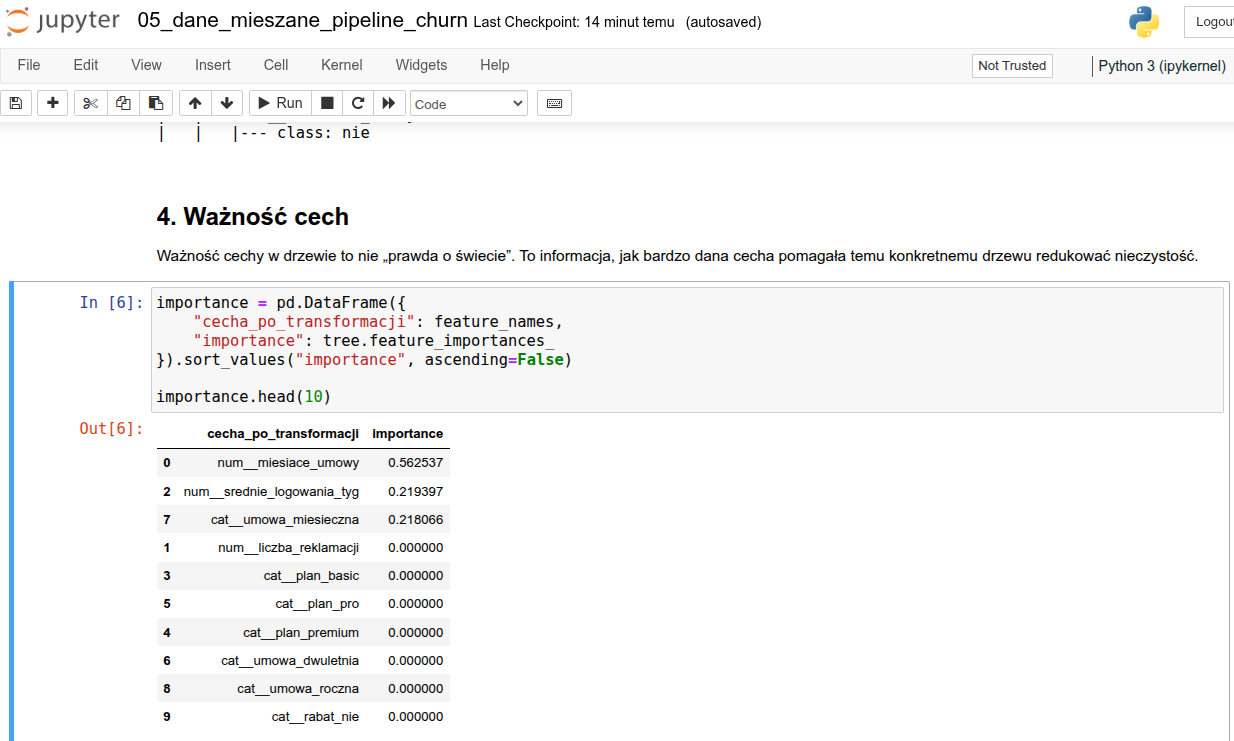

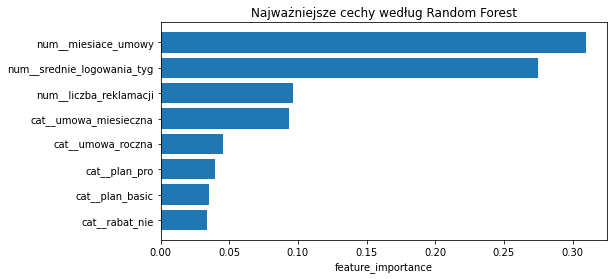

In [14]:
top = forest_importance.head(8).iloc[::-1]

plt.figure(figsize=(8, 4))
plt.barh(top["cecha_po_transformacji"], top["importance"])
plt.xlabel("feature_importance")
plt.title("Najważniejsze cechy według Random Forest")
plt.show()

## 8. Czy da się narysować Random Forest?

Całego lasu nie rysujemy jako jednego drzewa, bo model składa się z wielu drzew. Możemy jednak narysować jedno wybrane drzewo z lasu, pamiętając, że to tylko fragment całego modelu.

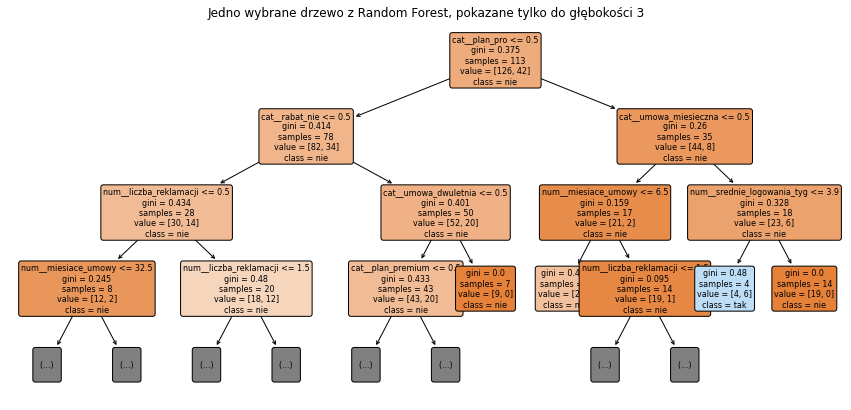

In [15]:
one_tree = forest.estimators_[0]

plt.figure(figsize=(15, 7))
plot_tree(
    one_tree,
    feature_names=feature_names,
    class_names=list(forest.classes_),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Jedno wybrane drzewo z Random Forest, pokazane tylko do głębokości 3")
plt.show()

## 9. Podsumowanie

Pojedyncze drzewo jest bardzo interpretowalne: można je narysować i zamienić na reguły. Random Forest jest mniej przejrzysty jako całość, ale często daje stabilniejsze predykcje, bo łączy decyzje wielu różnych drzew.

Najważniejsza intuicja:

```text
jedno drzewo  -> proste reguły, duża interpretowalność
wiele drzew   -> głosowanie, większa stabilność, mniejsza interpretowalność
```

## Ćwiczenia dla studentów

1. Zmień `n_estimators` na 10, 50 i 300. Czy wynik mocno się zmienia?
2. Zmień `max_depth` na `None`. Co dzieje się z accuracy na treningu i teście?
3. Porównaj ważność cech z pojedynczego drzewa i z Random Forest.
4. Dla wybranego klienta sprawdź, ile drzew głosowało na `tak`, a ile na `nie`.
5. Wyjaśnij, dlaczego Random Forest trudniej zamienić na jedną prostą regułę biznesową.

## Mini-ćwiczenie 1: ile drzew potrzebuje las?

Zmień `n_estimators` na:

```python
10, 50, 100, 300
```
Sprawdź:
```
accuracy test,
precision dla tak,
recall dla tak.
```
Czy więcej drzew zawsze daje dużą poprawę?


Kod:

```python
rows = []

for n in [10, 50, 100, 300]:
    pipe_tmp = Pipeline([
        ("prep", preprocess),
        ("forest", RandomForestClassifier(
            n_estimators=n,
            max_depth=6,
            min_samples_leaf=3,
            random_state=42
        ))
    ])

    pipe_tmp.fit(X_train, y_train)
    pred_tmp = pipe_tmp.predict(X_test)

    rows.append({
        "n_estimators": n,
        "accuracy": accuracy_score(y_test, pred_tmp),
        "precision_tak": precision_score(y_test, pred_tmp, pos_label="tak", zero_division=0),
        "recall_tak": recall_score(y_test, pred_tmp, pos_label="tak", zero_division=0),
        "f1_tak": f1_score(y_test, pred_tmp, pos_label="tak", zero_division=0),
    })

pd.DataFrame(rows)
```

## Mini-ćwiczenie 2: czy drzewa w lesie powinny być głębokie?

Zmień `max_depth` na:

```python
3, 6, None
```
Sprawdź, czy głębszy las poprawia wynik testowy.


Kod:

```python
rows = []

for depth in [3, 6, None]:
    pipe_tmp = Pipeline([
        ("prep", preprocess),
        ("forest", RandomForestClassifier(
            n_estimators=100,
            max_depth=depth,
            min_samples_leaf=3,
            random_state=42
        ))
    ])

    pipe_tmp.fit(X_train, y_train)
    pred_tmp = pipe_tmp.predict(X_test)

    rows.append({
        "max_depth": depth,
        "accuracy": accuracy_score(y_test, pred_tmp),
        "precision_tak": precision_score(y_test, pred_tmp, pos_label="tak", zero_division=0),
        "recall_tak": recall_score(y_test, pred_tmp, pos_label="tak", zero_division=0),
        "liczba_drzew": 100,
    })

pd.DataFrame(rows)
```

## Mini-ćwiczenie 3: próg decyzyjny

Domyślnie model przewiduje `tak`,
gdy prawdopodobieństwo klasy `tak` przekroczy około 0.5.

Zmień próg na `0.3` i sprawdź,
czy recall dla klasy `tak` rośnie.


In [19]:
proba_tak = forest_pipe.predict_proba(X_test)[:, list(forest_pipe.classes_).index("tak")]

for threshold in [0.5, 0.3]:
    pred_threshold = np.where(proba_tak >= threshold, "tak", "nie")

    print("threshold:", threshold)
    print("accuracy:", round(accuracy_score(y_test, pred_threshold), 3))
    print("precision_tak:", round(precision_score(y_test, pred_threshold, pos_label="tak", zero_division=0), 3))
    print("recall_tak:", round(recall_score(y_test, pred_threshold, pos_label="tak", zero_division=0), 3))
    print("-" * 40)

threshold: 0.5
accuracy: 0.75
precision_tak: 0.625
recall_tak: 0.25
----------------------------------------
threshold: 0.3
accuracy: 0.625
precision_tak: 0.379
recall_tak: 0.55
----------------------------------------
